In [43]:
from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [44]:
mu = jnp.log(0.5)

t_vec = jnp.linspace(0,5,100)

def rhs(t,state,args):

    x,y = state
    mu = args
    #exponentiate to enforce positivity
    mu = jnp.exp(mu)

    # Nonlinear cubic term introduces limit cycle behavior.
    dx = mu * (x - 1/3 * x**3 - y)
    # Coupling term creates slow–fast dynamics when mu is large.
    dy = 1/mu * x


    return jnp.array([dx,dy])

In [45]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts) #At which points to save the output
        )
  return solution.ys

In [46]:
# Initializing the random number generator
rng_key = jax.random.PRNGKey(0)

# Split the key to avoid reusing the same key.
# JAX requires explicit key management.
noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''
# Initial condition: x(0)=3.0, y(0)=0.5
full_state = model(t_vec,jnp.array([3.,0.5]),(mu))

# Generate noisy observations of the first state component x(t) with additive Gaussian noise ~N(0,1).
noise_std = 1.0
observations = full_state[:,0] + noise_std * jax.random.normal(noise_key,shape = full_state[:,0].shape)



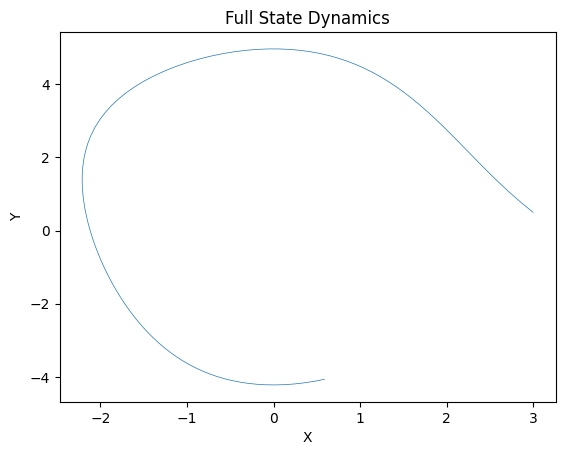

In [47]:
# Numerical solution of the ODE in x(t), y(t)
plt.plot(full_state[:,0],full_state[:,1],lw = 0.5)
plt.title('Full State Dynamics')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

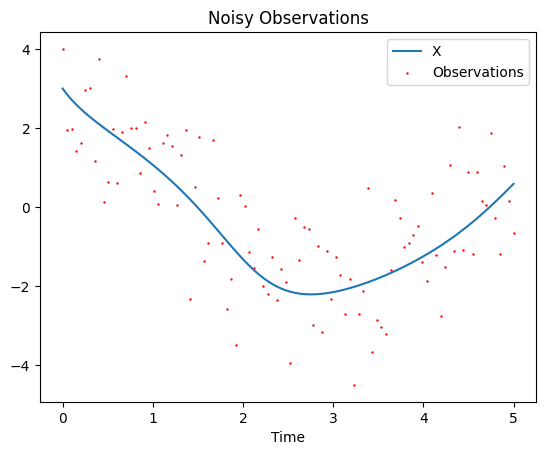

In [48]:
# Numerical solution of the ODE in t,x(t)
# We assume that the obervations are the red dots
plt.title('Noisy Observations')
plt.plot(t_vec,full_state[:,0],label = 'X')
plt.scatter(t_vec,observations,s = 0.5,color = 'red', label = 'Observations')
plt.xlabel('Time')
plt.legend()
plt.show()

In [49]:
'''Prior'''
tau = 5.0

@jax.jit
def log_prior(par,tau):
    mu = par
    return jax.scipy.stats.norm.logpdf(mu,scale = tau)

In [50]:
@jax.jit
def log_likelihood(par):
  mu = par
  model_output = model(t_vec,jnp.array([3.,0.5]),(mu))
  return jnp.sum(jax.scipy.stats.norm.logpdf(observations, model_output[:,0],scale = noise_std))

### Exercise A1 — Proposal Scale and Acceptance Rate

Modify the proposal standard deviation `proposal_std` in the random-walk Metropolis algorithm. Try values such as:
- 0.01
- 0.05
- 0.15
- 0.5
- 1.0

**Questions**

- What happens to the acceptance rate as `proposal_std` increases?
- Is a very high or very low acceptance rate desirable?


In [51]:
##MH
iterations = 1_000

proposal_stds = [0.01,0.05,0.15,0.5,1.0,2.0,3.0]

acceptance_rates = []

for std in proposal_stds:
    thetas = []
    LL = []

    theta_0 = 0.0
    thetas.append(theta_0)

    LL_0 = log_likelihood(theta_0) + log_prior(theta_0, tau)
    LL.append(LL_0)

    acceptances = []

    for iter in range(1, iterations):
        ##Proposal
        prop_key, rng_key = jax.random.split(rng_key)
        theta_prop = thetas[-1] + std * jax.random.normal(prop_key)

        LL_prop = log_likelihood(theta_prop) + log_prior(theta_prop, tau)
        alpha = LL_prop - LL[-1]

        rng_key, accept_key = jax.random.split(rng_key)
        if jnp.log(jax.random.uniform(minval=0.0, maxval=1.0, key=accept_key)) < alpha:
            LL.append(LL_prop)
            thetas.append(theta_prop)
            acceptances.append(1)

        else:
            LL.append(LL[-1])
            thetas.append(thetas[-1])
            acceptances.append(0)

        print(
            f"iteration: {iter} | Acceptance rate: {sum(acceptances) / iter:.2f} | mu: {jnp.exp(thetas[-1]):.4f}",
            end="\r",
        )

    acceptance_rates.append(sum(acceptances) / iter)

In [52]:
acceptance_rates

[0.993993993993994,
 0.94994994994995,
 0.8728728728728729,
 0.6276276276276276,
 0.44844844844844844,
 0.2172172172172172,
 0.15615615615615616]

The acceptance rate decreases as `proposal_std` increases. Too large of a proposal standard deviation leads to a low acceptance rate. A proposal standard deviation which is too small will yield a high acceptance rate but poor sampling, with a highly correlated chain. 

### Exercise A2 — Sensitivity to Initialization

Run the MCMC algorithm with different initial values:

- $ \theta_0 = 0 $
- $ \theta_0 = 5 $
- $ \theta_0 = -5 $

Keep all other settings fixed.


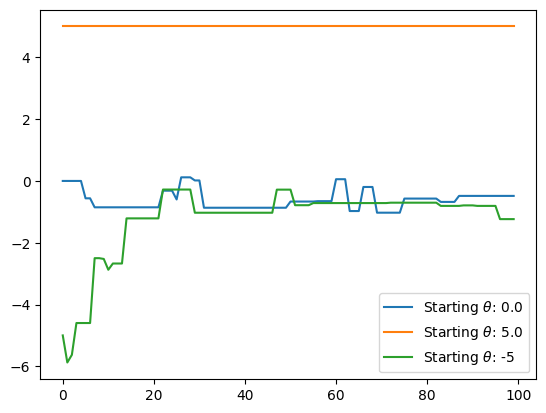

In [53]:
##MH
iterations = 100
theta0s = [0.,5.,-5]
proposal_std = 0.15

for theta_0 in theta0s:
    thetas = []
    LL = []
    acceptances = []

    sample_key, rng_key = jax.random.split(rng_key)

    thetas.append(theta_0)

    LL_0 = log_likelihood(theta_0) + log_prior(theta_0, tau)
    LL.append(LL_0)

    for iter in range(1, iterations):
        ##Proposal
        prop_key, rng_key = jax.random.split(rng_key)
        theta_prop = thetas[-1] + std * jax.random.normal(prop_key)

        LL_prop = log_likelihood(theta_prop) + log_prior(theta_prop, tau)
        alpha = LL_prop - LL[-1]

        rng_key, accept_key = jax.random.split(rng_key)
        if jnp.log(jax.random.uniform(minval=0.0, maxval=1.0, key=accept_key)) < alpha:
            LL.append(LL_prop)
            thetas.append(theta_prop)
            acceptances.append(1)

        else:
            LL.append(LL[-1])
            thetas.append(thetas[-1])
            acceptances.append(0)

        print(
            f"iteration: {iter} | Acceptance rate: {sum(acceptances) / iter:.2f} | mu: {jnp.exp(thetas[-1]):.4f}",
            end="\r",
        )

    plt.plot(thetas,label = f'Starting $\\theta$: {theta_0}')
plt.legend()
plt.show()

### Exercise A3 — Prior Sensitivity

Change the prior variance $( \tau^2 )$ in
$\theta \sim \mathcal{N}(0, \tau^2)$
to
- $ \tau = 0.1 $
- $ \tau = 1 $
- $ \tau = 20 $

**Questions**

- How does tightening or loosening the prior affect the posterior?

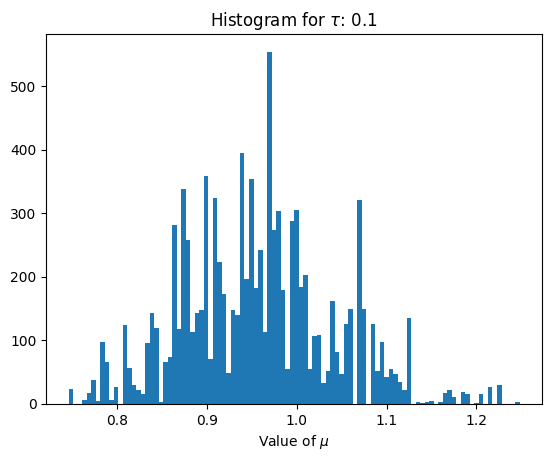

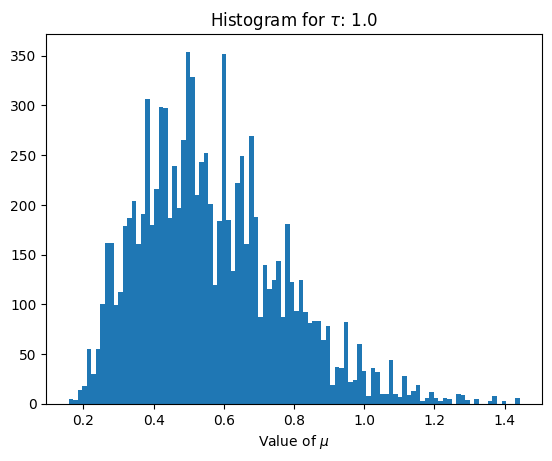

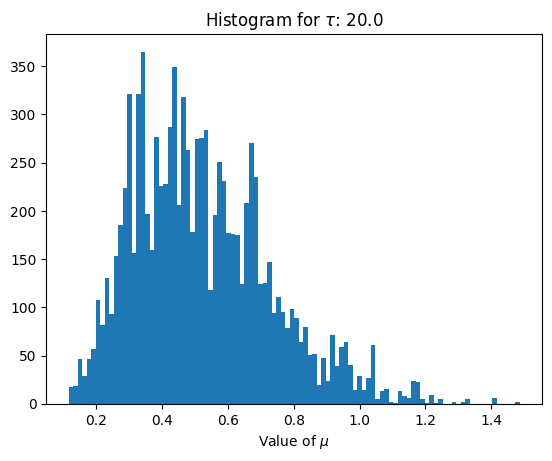

In [54]:
##MH
iterations = 10_000
taus = [0.1,1.,20.]
proposal_std = 0.15

for tau_val in taus:
    thetas = []
    LL = []
    acceptances = []

    sample_key, rng_key = jax.random.split(rng_key)

    theta_0 = 0.

    thetas.append(theta_0)

    LL_0 = log_likelihood(theta_0) + log_prior(theta_0, tau_val)
    LL.append(LL_0)

    for iter in range(1, iterations):
        ##Proposal
        prop_key, rng_key = jax.random.split(rng_key)
        theta_prop = thetas[-1] + std * jax.random.normal(prop_key)

        LL_prop = log_likelihood(theta_prop) + log_prior(theta_prop, tau_val)
        alpha = LL_prop - LL[-1]

        rng_key, accept_key = jax.random.split(rng_key)
        if jnp.log(jax.random.uniform(minval=0.0, maxval=1.0, key=accept_key)) < alpha:
            LL.append(LL_prop)
            thetas.append(theta_prop)
            acceptances.append(1)

        else:
            LL.append(LL[-1])
            thetas.append(thetas[-1])
            acceptances.append(0)

        print(
            f"iteration: {iter} | Acceptance rate: {sum(acceptances) / iter:.2f} | mu: {jnp.exp(thetas[-1]):.4f}",
            end="\r",
        )
    burn_in = 100
    plt.title(f"Histogram for $\\tau$: {tau_val}")
    plt.hist(jnp.exp(jnp.array(thetas[burn_in:])),bins = 100)
    plt.xlabel('Value of $\\mu$')
    plt.show()

The prior can improve inference in the low-data regime. However a prior which is too strict can lead to unintended results if there is a mismatch between the likelihood and the prior. Well optimized priors can improve acceptance rates and encode constraints in the parameter space. 

### Exercise A4 — Observation Noise Misspecification

Generate synthetic data using $\sigma_{\text{true}} = 1$

But perform inference assuming:

- $ \sigma = 0.5 $
- $ \sigma = 2.0 $

**Questions**

- How does the posterior uncertainty change?
- Does the posterior mean shift?
- Why does noise misspecification affect parameter inference?


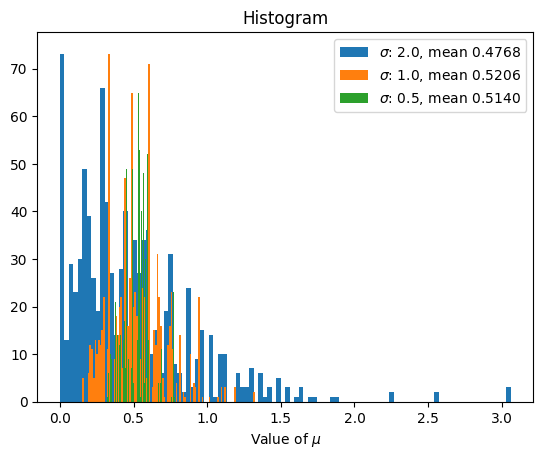

In [57]:
##MH
@jax.jit
def log_likelihood(par, sig):
    mu = par
    model_output = model(t_vec, jnp.array([3.0, 0.5]), (mu))
    return jnp.sum(
        jax.scipy.stats.norm.logpdf(observations, model_output[:, 0], scale=sig)
    )


iterations = 1_000
sigmas = [2.0, 1.0, 0.5]
proposal_std = 0.15

for sig in sigmas:
    thetas = []
    LL = []
    acceptances = []

    sample_key, rng_key = jax.random.split(rng_key)

    theta_0 = 0.0

    thetas.append(theta_0)

    LL_0 = log_likelihood(theta_0, sig) + log_prior(theta_0, tau_val)
    LL.append(LL_0)

    for iter in range(1, iterations):
        ##Proposal
        prop_key, rng_key = jax.random.split(rng_key)
        theta_prop = thetas[-1] + std * jax.random.normal(prop_key)

        LL_prop = log_likelihood(theta_prop, sig) + log_prior(theta_prop, tau_val)
        alpha = LL_prop - LL[-1]

        rng_key, accept_key = jax.random.split(rng_key)
        if jnp.log(jax.random.uniform(minval=0.0, maxval=1.0, key=accept_key)) < alpha:
            LL.append(LL_prop)
            thetas.append(theta_prop)
            acceptances.append(1)

        else:
            LL.append(LL[-1])
            thetas.append(thetas[-1])
            acceptances.append(0)

        print(
            f"iteration: {iter} | Acceptance rate: {sum(acceptances) / iter:.2f} | mu: {jnp.exp(thetas[-1]):.4f}",
            end="\r",
        )
    burn_in = 100
    plt.title("Histogram")

    plt.hist(
        jnp.exp(jnp.array(thetas[burn_in:])),
        bins=100,
        label=f"$\\sigma$: {sig}, mean {jnp.mean(jnp.exp(jnp.array(thetas[burn_in:]))):.4f}",
    )

plt.legend()
plt.xlabel("Value of $\\mu$")
plt.show()

Larger values of $\sigma$ lead to increased variance in the posterior distribution. The posterior mean shouldn't shift significantly, $\sigma$ only affects the posterior variance. As $\sigma$ increases so too does the posterior uncertainty. Misspecifying $\sigma$ can lead to a overabundance or lack of confidence in the parameter estimates. 

### Exercise B1 — Infer Noise Level

Extend the parameter vector to $(\theta, \eta)$, where $\mu = \exp(\theta)$, $\sigma = \exp(\eta)$.
Apply independent Gaussian priors on $\theta$ and $\eta$.

1. Modify the log-likelihood to depend on $ \sigma $.
2. Implement a 2D random-walk Metropolis sampler.
3. Plot the joint posterior samples.

**Questions**

- Is there posterior correlation between $ \mu $ and $ \sigma $?
- Does inference become harder in higher dimension?

In [58]:
@jax.jit
def log_likelihood(par):
  mu,eta = par
  model_output = model(t_vec,jnp.array([3.,0.5]),(mu))
  return jnp.sum(jax.scipy.stats.norm.logpdf(observations, model_output[:,0],scale = jnp.exp(eta)))

tau = 5.0
std = 0.1
iterations = 10_000

@jax.jit
def log_prior(par,tau):
    mu,eta = par
    return jax.scipy.stats.norm.logpdf(mu,scale = tau) + jax.scipy.stats.norm.logpdf(eta,scale = tau)

thetas = []
LL = []
acceptances = []

sample_key, rng_key = jax.random.split(rng_key)

theta_0 = jnp.log(jnp.array([0.5,0.5]))

thetas.append(theta_0)

LL_0 = log_likelihood(theta_0) + log_prior(theta_0, tau_val)
LL.append(LL_0)

for iter in range(1, iterations):
    ##Proposal
    prop_key, rng_key = jax.random.split(rng_key)
    theta_prop = jax.random.multivariate_normal(prop_key,thetas[-1],(std**2) * jnp.eye(len(thetas[-1])))

    LL_prop = log_likelihood(theta_prop) + log_prior(theta_prop, tau_val)
    alpha = LL_prop - LL[-1]

    rng_key, accept_key = jax.random.split(rng_key)
    if jnp.log(jax.random.uniform(minval=0.0, maxval=1.0, key=accept_key)) < alpha:
        LL.append(LL_prop)
        thetas.append(theta_prop)
        acceptances.append(1)

    else:
        LL.append(LL[-1])
        thetas.append(thetas[-1])
        acceptances.append(0)

    par = jnp.exp(thetas[-1])

    print(
        f"iteration: {iter} | Acceptance rate: {sum(acceptances) / iter:.2f} | mu: {par[0]:.4f}, sig: {par[1]:.4f}",
        end="\r",
    )


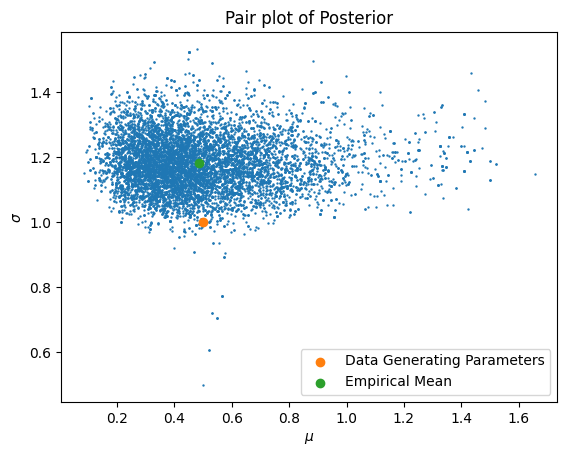

In [59]:
thetas = jnp.exp(jnp.array(thetas))
theta_mean = jnp.mean(thetas, axis=0)
burn_in = 1000
true_val = jnp.array([0.5, 1.0])
plt.title("Pair plot of Posterior")
plt.scatter(thetas[:, 0], thetas[:, 1], s=0.5)
plt.scatter(true_val[0], true_val[1], label="Data Generating Parameters")
plt.scatter(theta_mean[0],theta_mean[1], label="Empirical Mean")
plt.xlabel("$\\mu$")
plt.ylabel("$\\sigma$")
plt.legend()
plt.show()


In [61]:
corr_matrix = jnp.corrcoef(thetas.T)

print(f"The Pearson Correlation Coefficient: {corr_matrix[0,1]}")


The Pearson Correlation Coefficient: -0.015429382212460041


There is no posterior correlation between $\mu$ and $\sigma$. This is to be expected as the two variables have no functional relationship. Inference becomes more difficult here, note we had to adjust the proposal standard deviation to improve acceptance rates. 